<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB
None
       Drug Dosage (mg)  Systolic Blood Pressure (mmHg)  Heart Rate (BPM)  \
count        500.000000                      500.000000        500.000000   
mean          -0.037761                        0.214957          0.062871   
std            0.979891                        1.247567          0.971978   
min           -3.019512                     

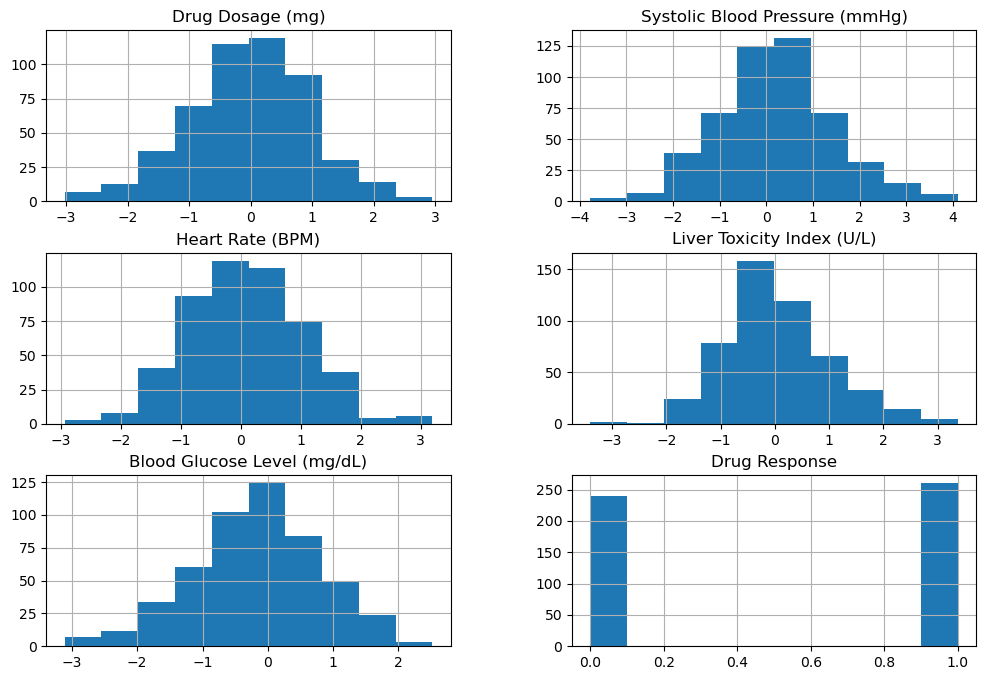

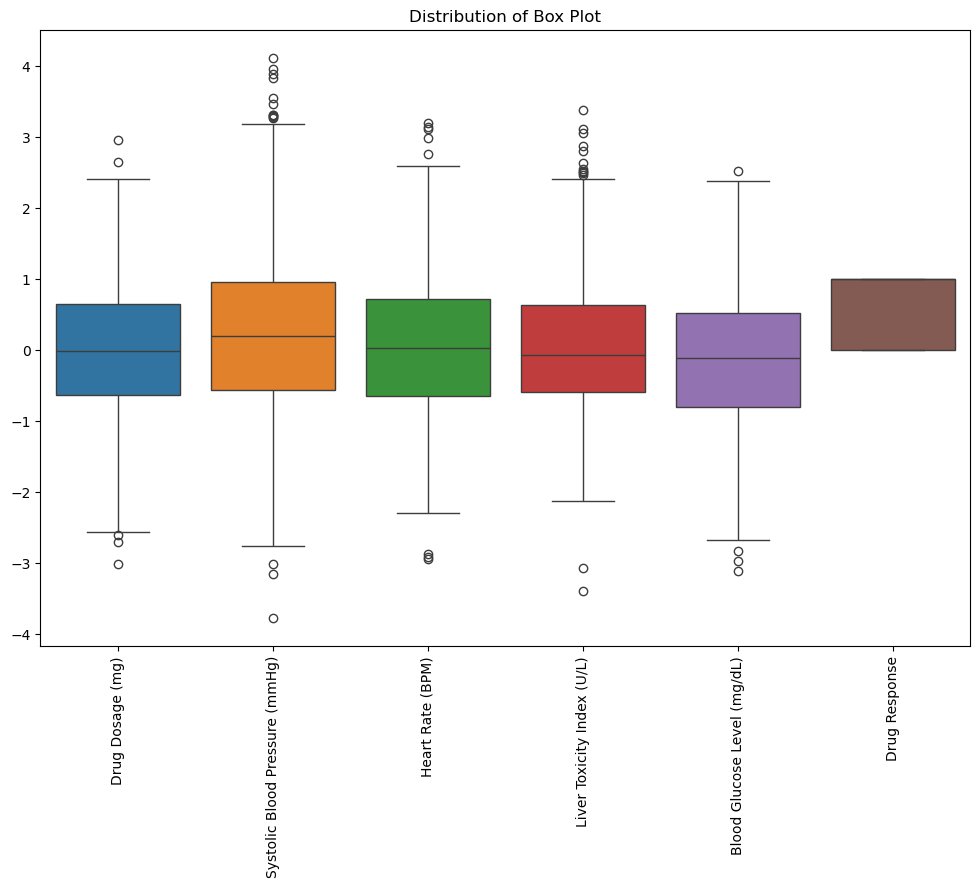

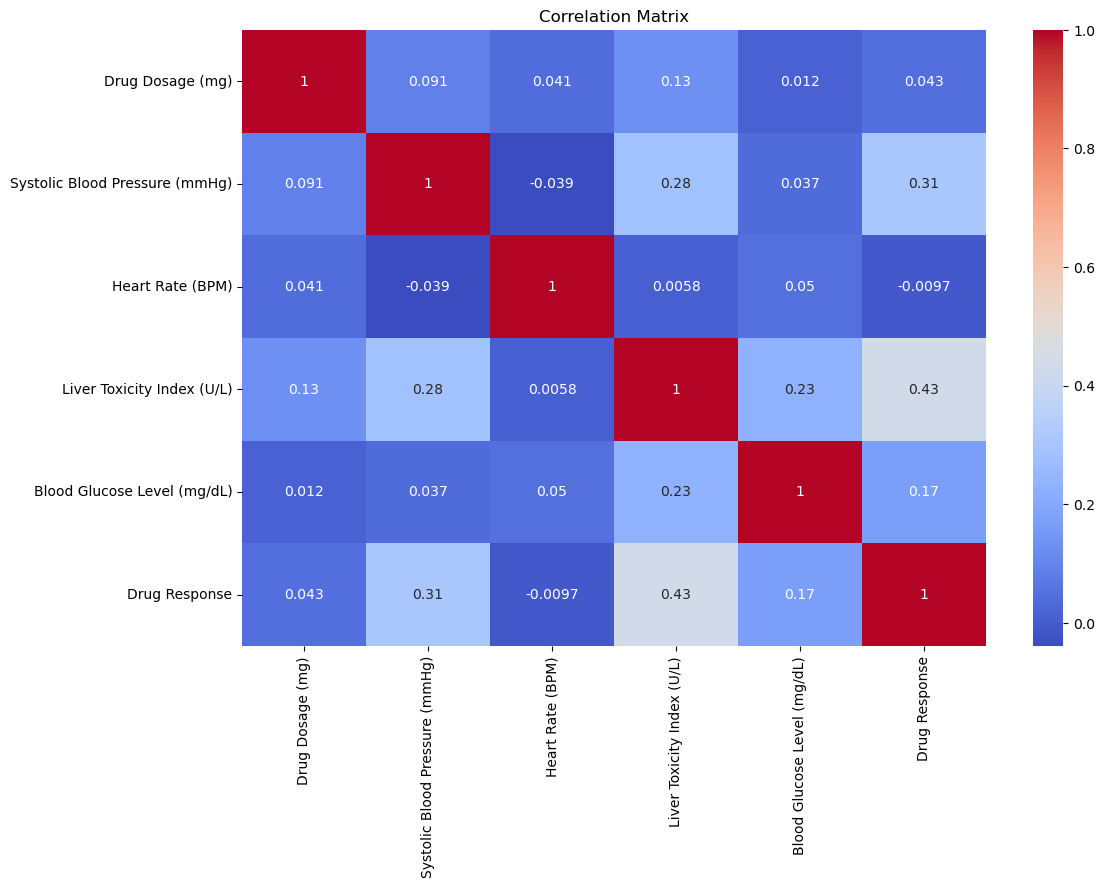

['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)', 'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)', 'Blood Glucose Level (mg/dL)', 'Drug Response']


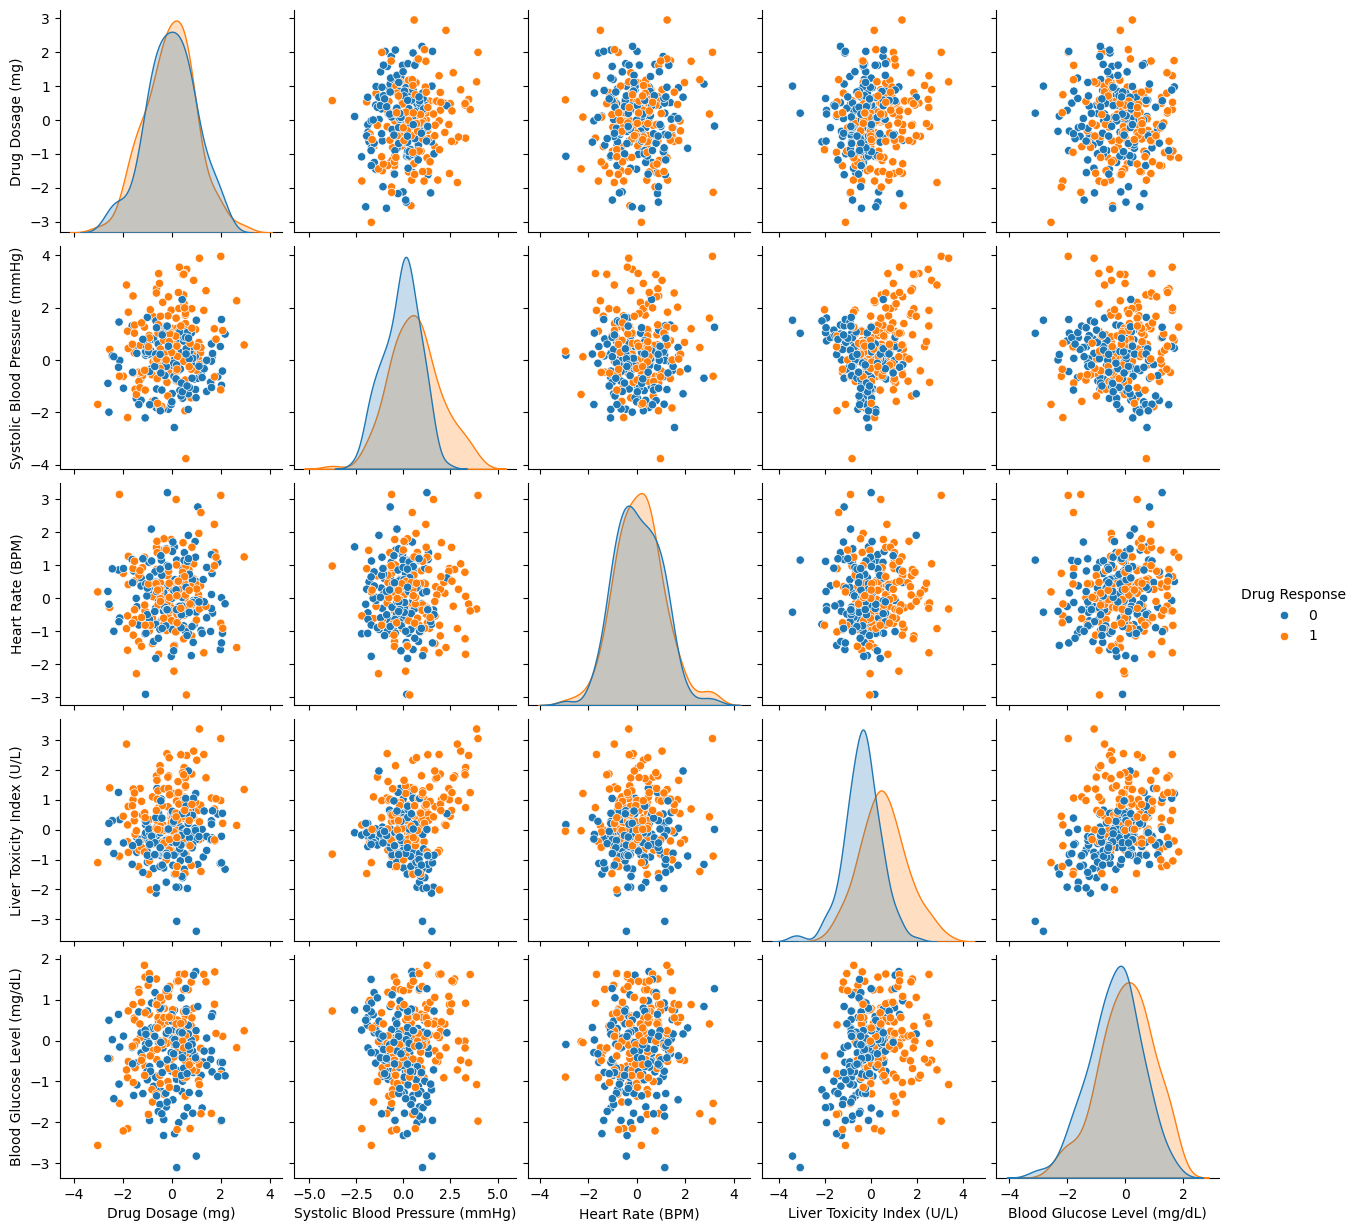

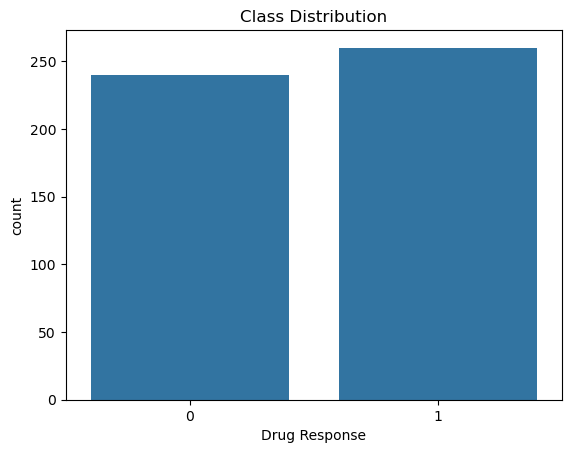

LINEAR SVM RESULTS

              precision    recall  f1-score   support

           0       0.69      0.77      0.73        48
           1       0.76      0.67      0.71        52

    accuracy                           0.72       100
   macro avg       0.72      0.72      0.72       100
weighted avg       0.72      0.72      0.72       100



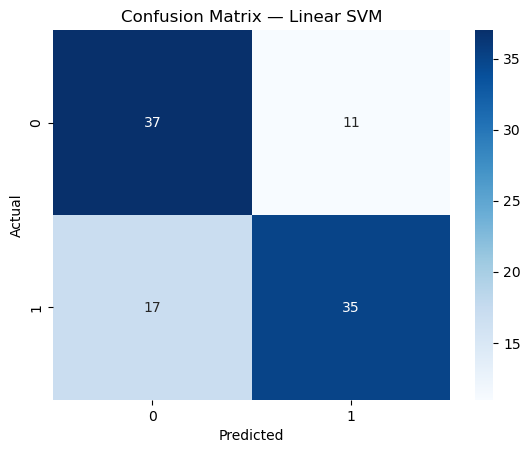

Best Parameters: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
        Accuracy        F1
linear      0.72  0.719664
rbf         0.77  0.768957
poly        0.66  0.660000


In [5]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv(
    r"C:\Users\NIKHIL\Downloads\data science assignment\data science assignment\Pharma_Industry.csv"
)

# ==========================================
# DATA OVERVIEW
# ==========================================

print(df.info())

print(df.describe())

print(df.head())

print(df.isnull().sum())

# ==========================================
# VISUALIZATION
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

df.hist(figsize=(12,8))

plt.show()

plt.figure(figsize=(12,8))

sns.boxplot(df)

plt.title("Distribution of Box Plot")

plt.xticks(rotation=90)

plt.show()

plt.figure(figsize=(12,8))

plt.title("Correlation Matrix")

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.show()

# ==========================================
# ENCODING
# ==========================================

cat_cols = df.select_dtypes(include="object").columns

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# ==========================================
# FEATURES & TARGET
# ==========================================

print(df.columns.tolist())

X = df.drop("Drug Response", axis=1)

y = df["Drug Response"]

# ==========================================
# FEATURE SCALING
# ==========================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ==========================================
# TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==========================================
# PAIRPLOT
# ==========================================

sns.pairplot(df.sample(300), hue="Drug Response")

plt.show()

# ==========================================
# CLASS DISTRIBUTION
# ==========================================

sns.countplot(x=df["Drug Response"])

plt.title("Class Distribution")

plt.show()

# ==========================================
# LINEAR SVM
# ==========================================

svm_linear = SVC(kernel="linear")

svm_linear.fit(X_train, y_train)

y_pred = svm_linear.predict(X_test)

print("LINEAR SVM RESULTS\n")

print(classification_report(y_test, y_pred))

# ==========================================
# CONFUSION MATRIX
# ==========================================

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix — Linear SVM")

plt.show()

# ==========================================
# HYPERPARAMETER TUNING
# ==========================================

param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf", "poly"],
    "gamma": ["scale", 0.1, 0.01]
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

# ==========================================
# KERNEL COMPARISON
# ==========================================

kernels = ["linear", "rbf", "poly"]

results = {}

for k in kernels:

    model = SVC(kernel=k)

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    results[k] = {
        "Accuracy": accuracy_score(y_test, preds),

        "F1": f1_score(
            y_test,
            preds,
            average="weighted"
        )
    }

print(pd.DataFrame(results).T)

In [4]:
print(df.columns.tolist())

['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)', 'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)', 'Blood Glucose Level (mg/dL)', 'Drug Response']
